# 04 - Price Error Analysis

**Mục tiêu:** phân tích sai số của final model, không train lại baseline, feature selection hay tuning.

**Input:** artifact của notebook 03 và dữ liệu Gold để join thông tin listing. **Output:** `ml/outputs/price_error_analysis/`.

In [1]:
from __future__ import annotations

import json
import sys
from datetime import datetime, timezone
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.motherduck import close_connection, connect_motherduck
from utils.sql import query_dataframe

RANDOM_STATE = 42
SOURCE_TABLE = "gold.gold_price_model_features"
MODEL_OUTPUT = PROJECT_ROOT / "ml" / "outputs" / "price_modeling"

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal, spearmanr

ERROR_OUTPUT = PROJECT_ROOT / "ml" / "outputs" / "price_error_analysis"
for folder in ("csv", "charts", "summary"):
    (ERROR_OUTPUT / folder).mkdir(parents=True, exist_ok=True)
predictions = pd.read_csv(MODEL_OUTPUT / "csv" / "15_final_test_predictions.csv")
metrics = pd.read_csv(MODEL_OUTPUT / "csv" / "14_final_test_metrics.csv")

required_prediction_columns = {
    "listing_id", "actual_log_price", "predicted_log_price", "residual_log",
    "actual_price", "predicted_price", "absolute_error_price",
}
missing_prediction_columns = required_prediction_columns.difference(predictions.columns)
if missing_prediction_columns:
    raise ValueError(f"Prediction artifact missing columns: {sorted(missing_prediction_columns)}")
if predictions["listing_id"].duplicated().any():
    raise ValueError("Prediction artifact contains duplicate listing_id values.")


def rmse(y_true, y_pred):
    residuals = np.asarray(y_true, dtype=float) - np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean(np.square(residuals))))
    raise ValueError("test_predictions.csv có listing_id trùng.")

## 1. Join dữ liệu Gold và kiểm tra tính toàn vẹn

In [2]:
connection = connect_motherduck(read_only=True)
try:
    gold = query_dataframe(connection, f"select * from {SOURCE_TABLE}")
finally:
    close_connection(connection)
if gold["listing_id"].duplicated().any():
    raise ValueError("Gold feature mart có listing_id trùng.")
analysis = predictions.merge(gold, on="listing_id", how="left", validate="one_to_one", suffixes=("", "_gold"))
analysis["residual_price"] = analysis["actual_price"] - analysis["predicted_price"]
analysis["absolute_percentage_error"] = (
    analysis["absolute_error_price"] / analysis["actual_price"].abs().clip(lower=1e-9)
)
if len(analysis) != len(predictions) or analysis["log_price"].isna().any():
    raise ValueError("Join Gold làm mất hoặc nhân bản dữ liệu test.")

## 2. Tổng quan và phân tích theo nhóm

    Các nhóm dưới 30 quan sát được đánh dấu `small_sample_flag`, không dùng để kết luận mạnh.

In [3]:
def group_summary(data, column):
    grouped = data.dropna(subset=[column]).groupby(column, observed=True)
    summary = grouped.agg(count=("listing_id", "size"), actual_mean=("actual_price", "mean"), actual_median=("actual_price", "median"), predicted_mean=("predicted_price", "mean"), predicted_median=("predicted_price", "median"), mae=("absolute_error_price", "mean"), median_ae=("absolute_error_price", "median"), bias=("residual_price", "mean"), mape=("absolute_percentage_error", "mean")).reset_index()
    summary["rmse"] = grouped.apply(lambda item: rmse(item["actual_price"], item["predicted_price"]), include_groups=False).values
    summary["small_sample_flag"] = summary["count"] < 30
    return summary.sort_values(["mae", "count"], ascending=[False, False])

analysis["price_segment"] = pd.cut(analysis["actual_price"], [-np.inf, 1000, 2000, 5000, 10000, np.inf], labels=["< 1,000 THB", "1,000-2,000 THB", "2,000-5,000 THB", "5,000-10,000 THB", "> 10,000 THB"])
analysis["property_group"] = analysis.get("property_type", pd.Series("Unknown", index=analysis.index)).fillna("Unknown").astype(str).str.split().str[0]
group_columns = [column for column in ["price_segment", "neighbourhood", "room_type", "property_group"] if column in analysis]
group_filenames = {
    "price_segment": "02_error_by_price_segment.csv",
    "neighbourhood": "03_error_by_neighbourhood.csv",
    "room_type": "04_error_by_room_type.csv",
    "property_group": "05_error_by_property_group.csv",
}
for column in group_columns:
    group_summary(analysis, column).to_csv(ERROR_OUTPUT / "csv" / group_filenames[column], index=False)

overall = pd.DataFrame([{**metrics.iloc[0].to_dict(), "mean_residual_log": analysis["residual_log"].mean(), "overprediction_rate": float((analysis["residual_price"] < 0).mean()), "underprediction_rate": float((analysis["residual_price"] > 0).mean())}])
overall.to_csv(ERROR_OUTPUT / "summary" / "01_error_analysis_summary.csv", index=False)

## 3. Biểu đồ và các listing có sai số lớn

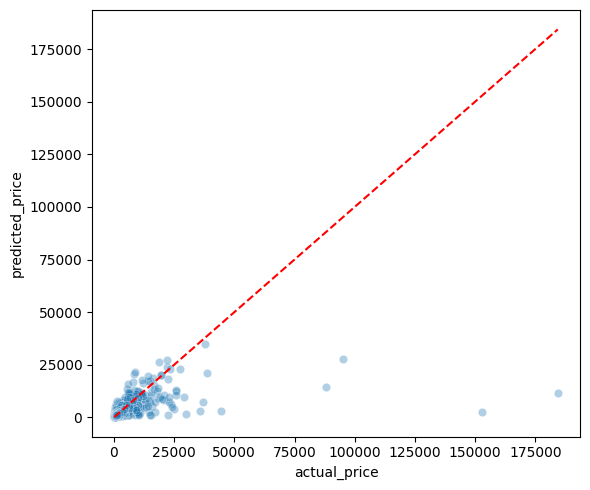

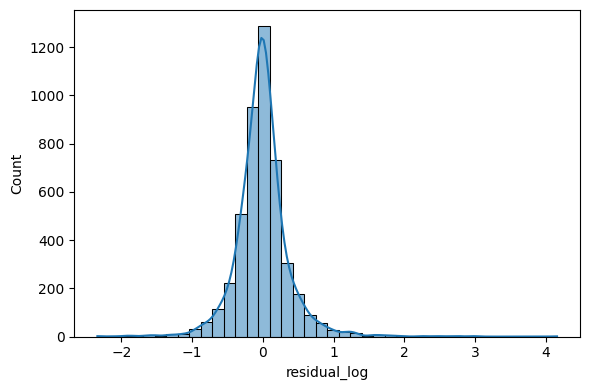

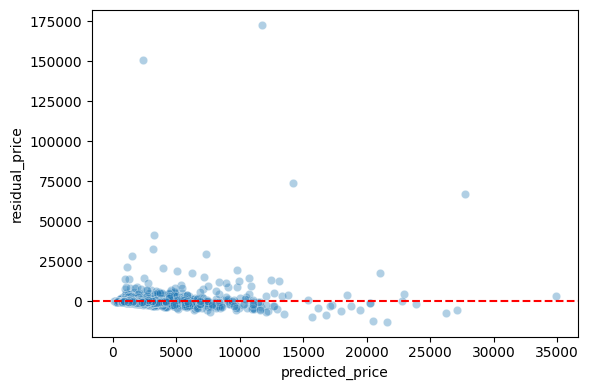

In [4]:
def save_chart(filename):
    plt.tight_layout(); plt.savefig(ERROR_OUTPUT / "charts" / filename, dpi=150, bbox_inches="tight"); plt.show()

plt.figure(figsize=(6, 5)); sns.scatterplot(data=analysis, x="actual_price", y="predicted_price", alpha=.35); plt.plot([analysis.actual_price.min(), analysis.actual_price.max()], [analysis.actual_price.min(), analysis.actual_price.max()], "r--"); save_chart("01_actual_vs_predicted.png")
plt.figure(figsize=(6, 4)); sns.histplot(analysis["residual_log"], bins=40, kde=True); save_chart("02_residual_distribution_log.png")
plt.figure(figsize=(6, 4)); sns.scatterplot(data=analysis, x="predicted_price", y="residual_price", alpha=.35); plt.axhline(0, color="red", linestyle="--"); save_chart("03_residual_vs_predicted_price.png")

top_absolute = analysis.nlargest(20, "absolute_error_price")
top_over = analysis.nsmallest(20, "residual_price")
top_under = analysis.nlargest(20, "residual_price")
top_absolute.to_csv(ERROR_OUTPUT / "csv" / "06_top_absolute_errors.csv", index=False)
top_over.to_csv(ERROR_OUTPUT / "csv" / "07_top_overpredictions.csv", index=False)
top_under.to_csv(ERROR_OUTPUT / "csv" / "08_top_underpredictions.csv", index=False)

## 4. Kiểm định có ích và kết luận

    Spearman đo quan hệ đơn điệu giữa giá thực tế và sai số tuyệt đối; Kruskal-Wallis chỉ được báo cáo khi có nhiều hơn một nhóm.

In [ ]:
tests = [{"test": "spearman_actual_price_absolute_error", "statistic": spearmanr(analysis["actual_price"], analysis["absolute_error_price"]).statistic, "p_value": spearmanr(analysis["actual_price"], analysis["absolute_error_price"]).pvalue}]
for column in group_columns:
    samples = [group["absolute_error_price"].values for _, group in analysis.dropna(subset=[column]).groupby(column, observed=True) if len(group) >= 30]
    if len(samples) >= 2:
        result = kruskal(*samples)
        tests.append({"test": f"kruskal_absolute_error_by_{column}", "statistic": result.statistic, "p_value": result.pvalue})
pd.DataFrame(tests).to_csv(ERROR_OUTPUT / "csv" / "09_statistical_tests.csv", index=False)

Kết luận cần đọc cùng count và small_sample_flag: nhóm MAE thấp là nơi mô hình tốt hơn; residual_price âm là overprediction, dương là underprediction. Các kiểm định mô tả khác biệt thống kê, không khẳng định nguyên nhân thực tế.


## Kết luận phân tích sai số

- **Hiệu năng tổng thể khá tốt trên scale log-price:** mô hình `XGBRegressor` với tập `Selected` đạt RMSE log `0,385`, MAE log `0,253` và R² `0,725`. Khi quy đổi về giá, RMSE là khoảng **4.071 THB** và MAE là khoảng **717 THB**.
- **Thiên lệch tổng thể nhỏ, nhưng hơi nghiêng về overprediction:** mean residual log là `-0,0069`; 53,1% listing bị dự báo cao hơn thực tế, so với 46,9% underprediction. Chênh lệch này không lớn, nhưng nên theo dõi khi calibrate mô hình.
- **Sai số tăng rất mạnh theo phân khúc giá.** Nhóm trên 10.000 THB có MAE khoảng **13.574 THB**, RMSE khoảng **29.483 THB** và bias dương lớn, cho thấy xu hướng underpredict listing giá cao. Ngược lại, nhóm dưới 1.000 THB có bias âm khoảng **-211 THB**, tức có xu hướng overpredict.
- **Mô hình hoạt động ổn hơn ở phân khúc giá trung bình:** 1.000–2.000 THB có MAE khoảng 269 THB; 2.000–5.000 THB có MAE khoảng 778 THB. Nhóm 5.000–10.000 THB có MAE khoảng 2.379 THB và cũng nghiêng về underprediction.
- **Theo loại phòng, Shared room là nhóm dễ dự báo nhất** (MAE khoảng 171 THB), trong khi Entire home/apt và Private room có RMSE cao do có các listing giá trị ngoại lai. Không nên rút kết luận mạnh cho các neighbourhood/property group có `small_sample_flag = true`; ví dụ Bangkok Noi có MAE cao nhưng chỉ 33 quan sát và bị ảnh hưởng bởi outlier giá cao.
- **Các listing sai số lớn nhất đều là listing cao giá bị underpredict.** Case lớn nhất có giá thực khoảng 184.368 THB nhưng model dự báo khoảng 11.740 THB. Đây là dấu hiệu nên bổ sung feature phân biệt listing luxury/outlier, hoặc cân nhắc mô hình/tầng phân khúc riêng cho đuôi giá cao.
- **Kiểm định xác nhận sai số không phân bổ đồng nhất:** Spearman giữa giá thực tế và absolute error là `0,476` (p-value rất nhỏ); Kruskal–Wallis theo phân khúc giá, neighbourhood, room type và property group đều có ý nghĩa thống kê. Đây là bằng chứng về khác biệt sai số giữa nhóm, không khẳng định quan hệ nhân quả.
